In [1]:
%load_ext autoreload

In [73]:
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import argparse
from tqdm import tqdm
import pandas as pd

In [76]:
from src.dataset import *

loader_tr, loader_val, res, num_classes, class_counts = load_data('cifar10', mb=256, scale='normal', cpus=1)

In [80]:
%autoreload 2
from results import load_model

args_dict = {'arch': 'resnet18',
             'type': 'posterior-network',
             'latent_dim': 4,
             'flow_length': 6,
             'flow_type': 'radial',}
             
args = argparse.Namespace(**args_dict)
fn = 'posterior-network-under-diffusion/0kb49gfy/checkpoints/epoch=199-step=39200.ckpt'
model = load_model(args, fn, res, num_classes, class_counts)

In [82]:
model.eval()

latents = []
layers = []
targets = []
with torch.no_grad(): 
    for data, target in tqdm(loader_val[0]):
        z = model.net_forward(data)
        l = model.process_batch_with_class_flow(z, target)
        latents.append(z)
        layers.append(l)
        targets.append(target)

latents = torch.cat(latents, dim=0)
targets = torch.cat(targets, dim=0)
layers = torch.cat(layers, dim=1)
latents.shape, targets.shape, layers.shape

100%|██████████| 100/100 [02:59<00:00,  1.79s/it]


(torch.Size([10000, 4]), torch.Size([10000]), torch.Size([6, 10000, 4]))

In [83]:
class_names = {
    0: 'airplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}
targets_names = [class_names[int(label)] for label in targets]

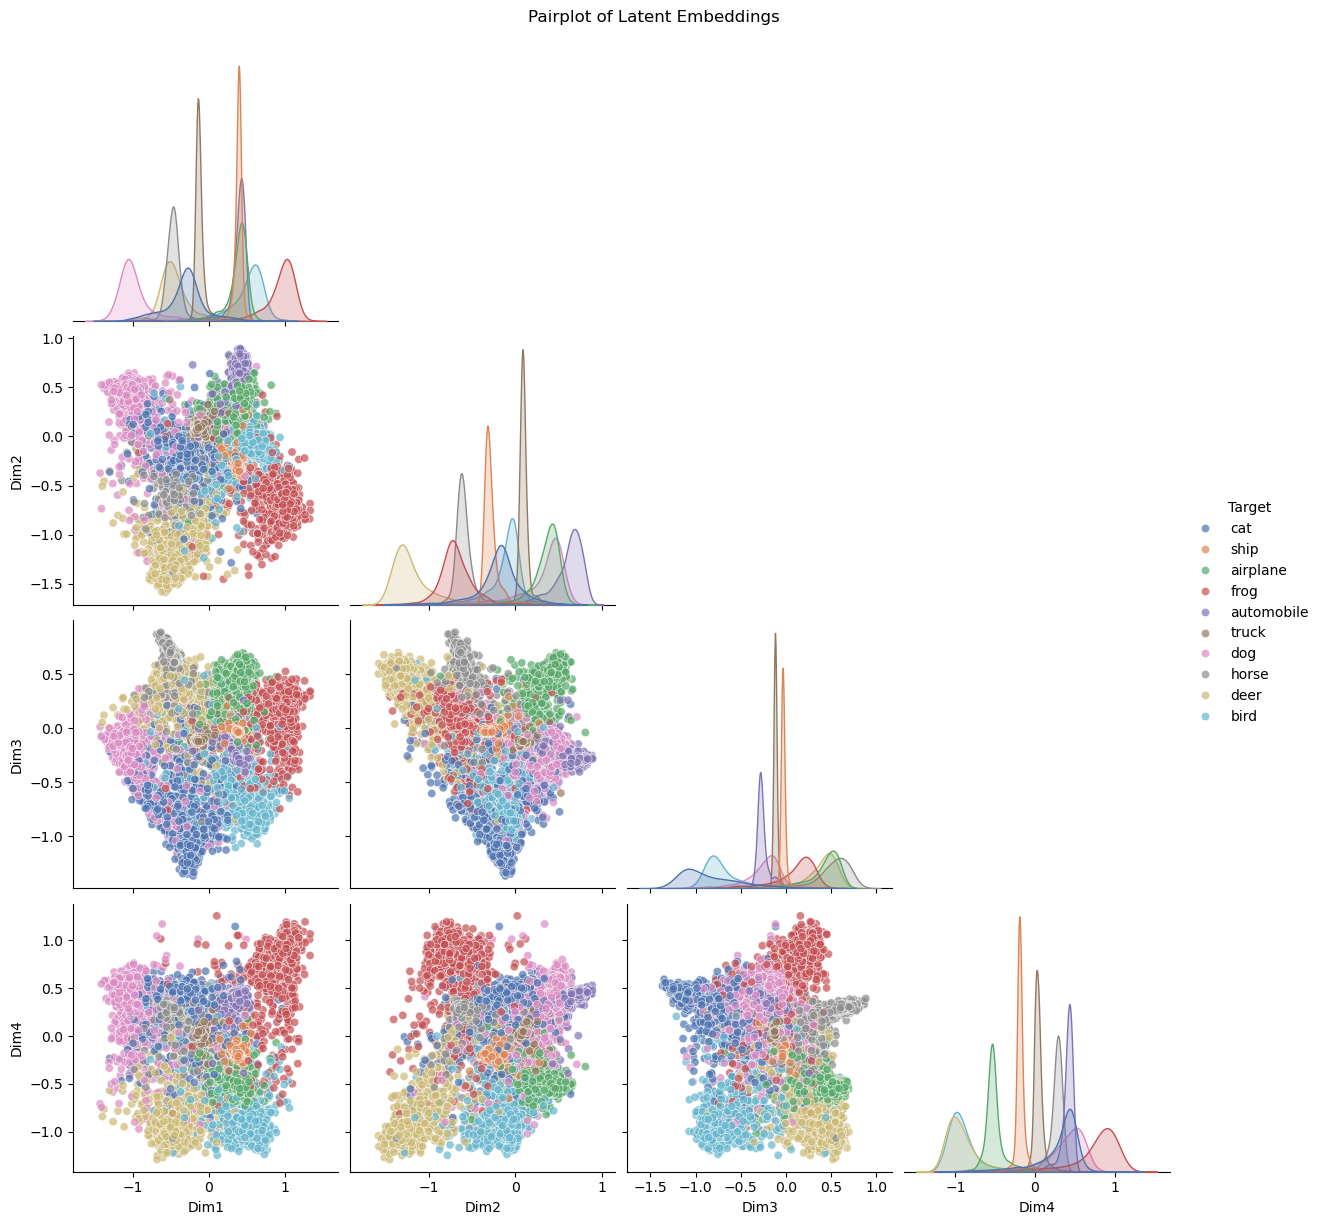

In [67]:
df = pd.DataFrame(outputs, columns=['Dim1', 'Dim2', 'Dim3', 'Dim4'])
df['Target'] = targets_names
pairplot = sns.pairplot(df, hue='Target', palette='deep', diag_kind='kde', plot_kws={'alpha': 0.7}, corner=True, height=3, aspect=1)
pairplot.fig.suptitle('Pairplot of Latent Embeddings', y=1.02)
pairplot.savefig("images/pairplot_latent.svg", format='svg')
plt.show()

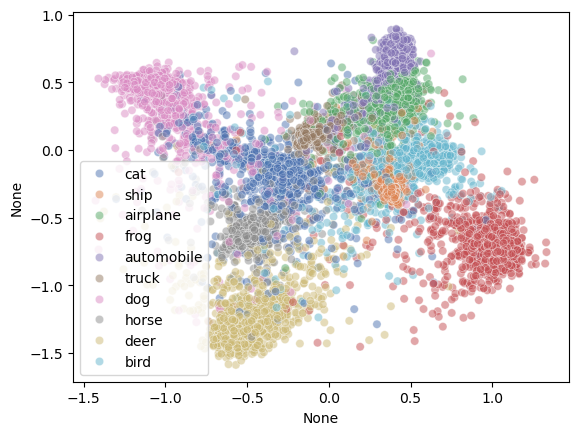

In [84]:
sns.scatterplot(x=latents[:, 0], y=latents[:, 1], hue=targets_names, palette='deep', alpha=0.5)
plt.show()

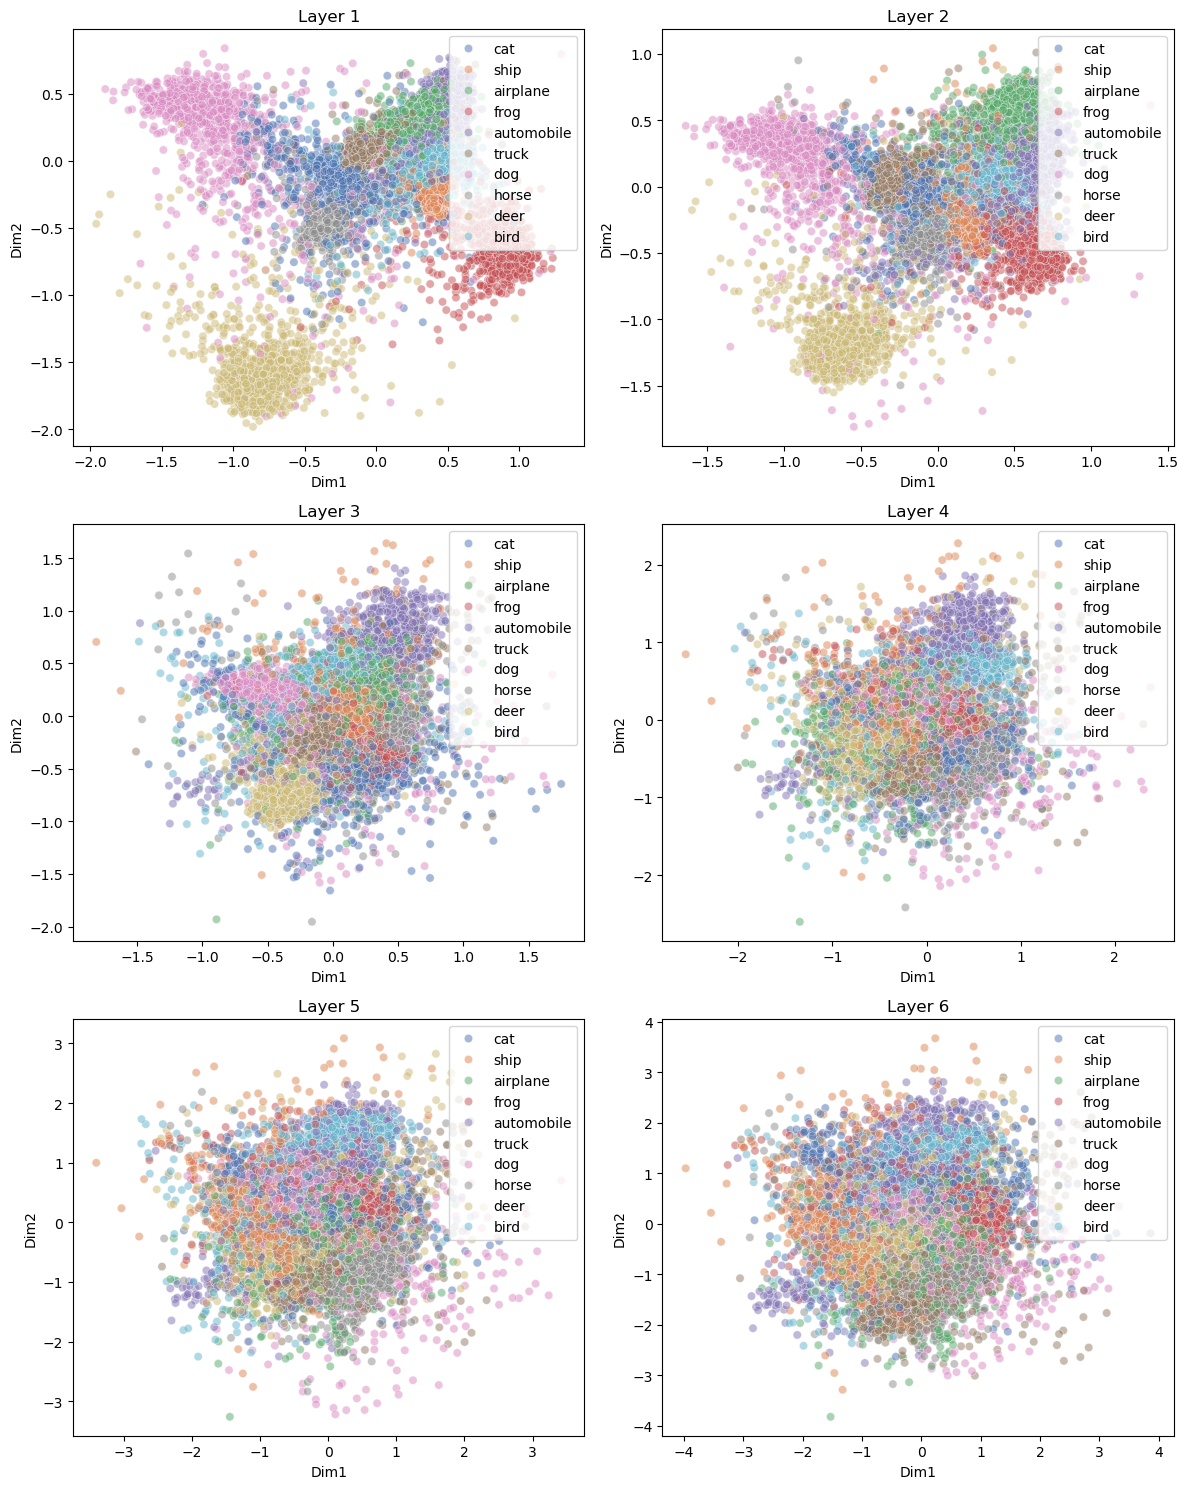

In [110]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    sns.scatterplot(x=layers[i, :, 0], y=layers[i, :, 1], hue=targets_names, palette='deep', ax=ax, alpha=0.5)
    ax.set_title(f'Layer {i+1}')
    ax.set_xlabel('Dim1')
    ax.set_ylabel('Dim2')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("images/scatter_flow.svg", format='svg')
plt.show()

In [86]:
from sklearn.manifold import TSNE

In [61]:
outputs_tsne = TSNE(n_components=2).fit_transform(outputs)
df_tsne = pd.DataFrame(outputs_tsne, columns=['t-SNE1', 't-SNE2'])
df_tsne['Target'] = targets_names

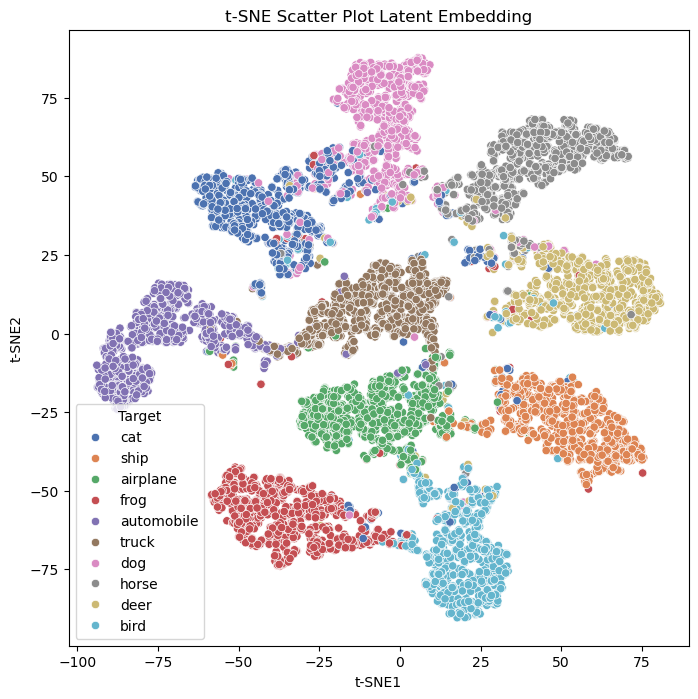

In [62]:
plt.figure(figsize=(8, 8))
ax = sns.scatterplot(data=df_tsne, x='t-SNE1', y='t-SNE2', hue='Target', palette='deep')
ax.set_title('t-SNE Scatter Plot Latent Embedding')

plt.savefig("images/tsne_latent.svg", format='svg')
plt.show()

In [103]:
tsne_results = [TSNE(n_components=2).fit_transform(layers[i]) for i in range(6)]

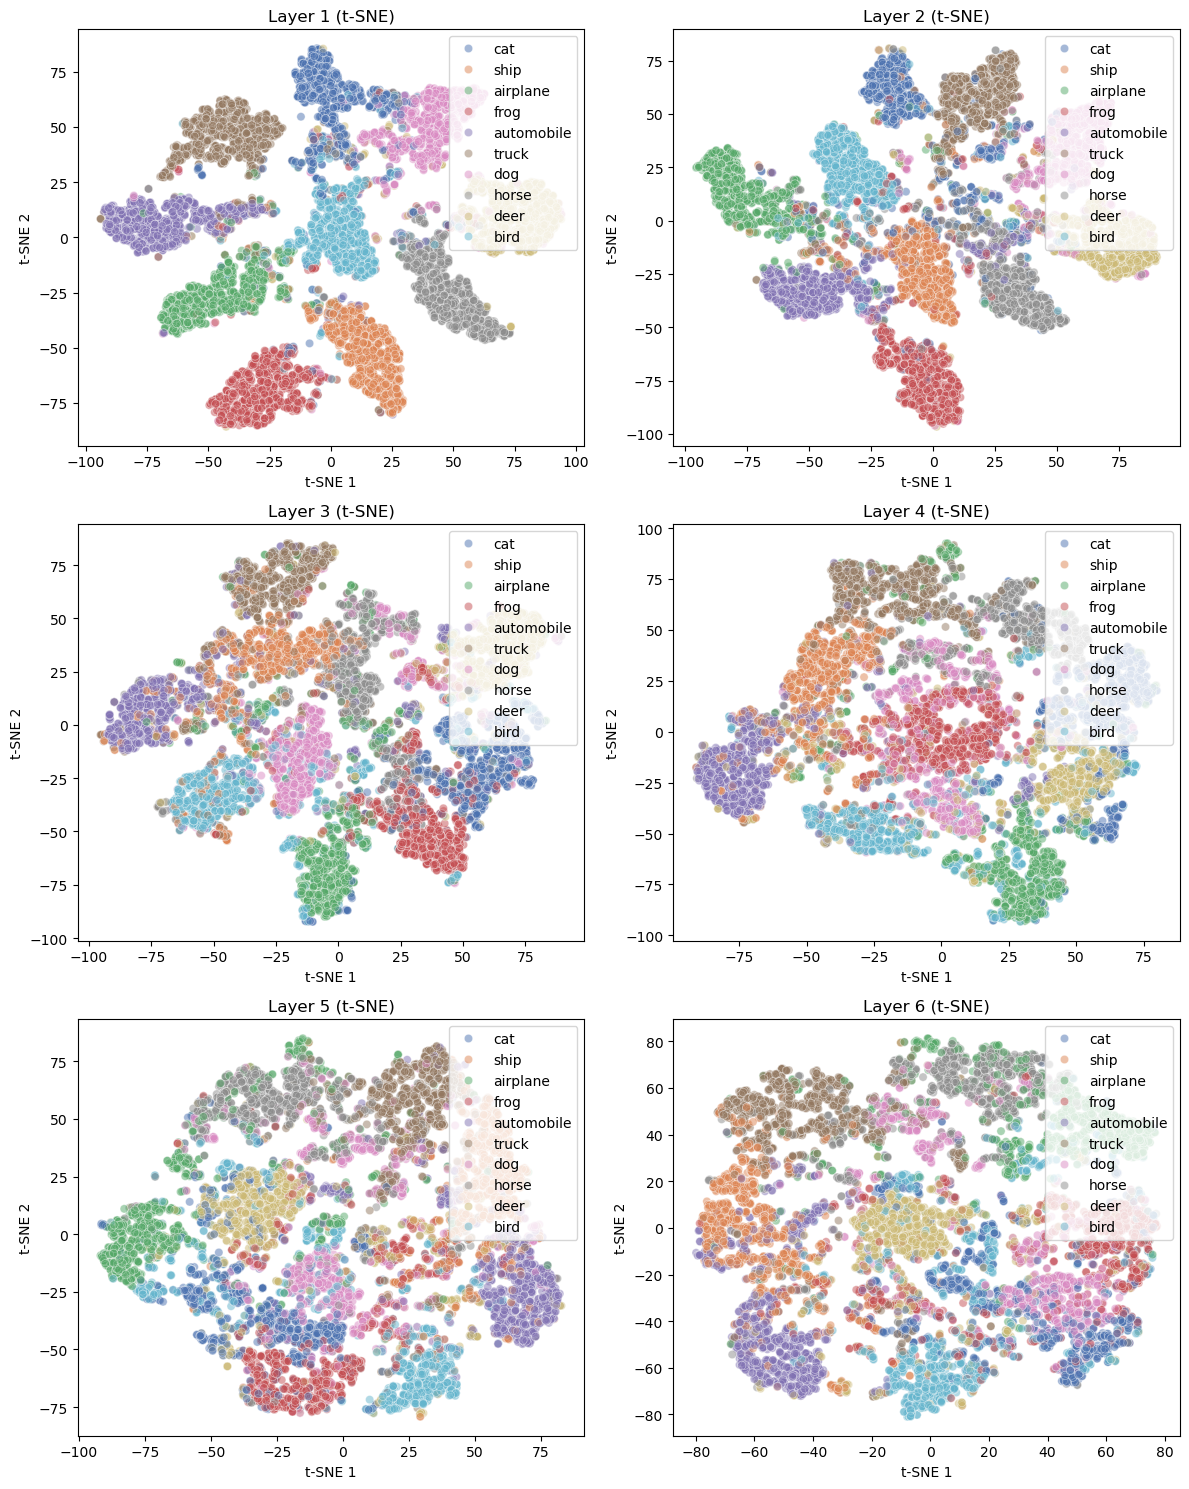

In [113]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    sns.scatterplot(x=tsne_results[i][:, 0], y=tsne_results[i][:, 1], hue=targets_names, palette='deep', ax=ax, alpha=0.5)
    ax.set_title(f'Layer {i+1} (t-SNE)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("images/tsne_flow.svg", format='svg')
plt.show()

In [90]:
import umap

2024-08-02 17:38:26.624325: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-02 17:38:26.624398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-02 17:38:26.625362: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [63]:
outputs_umap = umap.UMAP(n_components=2).fit_transform(outputs)

df_umap = pd.DataFrame(outputs_umap, columns=['UMAP1', 'UMAP2'])
df_umap['Target'] = targets_names

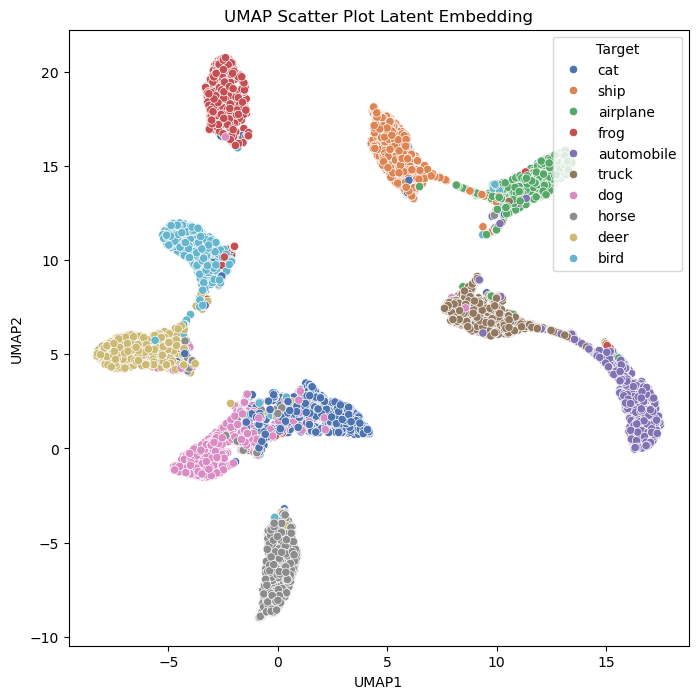

In [66]:
plt.figure(figsize=(8, 8))
ax = sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='Target', palette='deep')
ax.set_title('UMAP Scatter Plot Latent Embedding')

plt.savefig("images/umap_latent.svg", format='svg')
plt.show()

In [108]:
umap_results = [umap.UMAP(n_components=2).fit_transform(layers[i]) for i in range(6)]

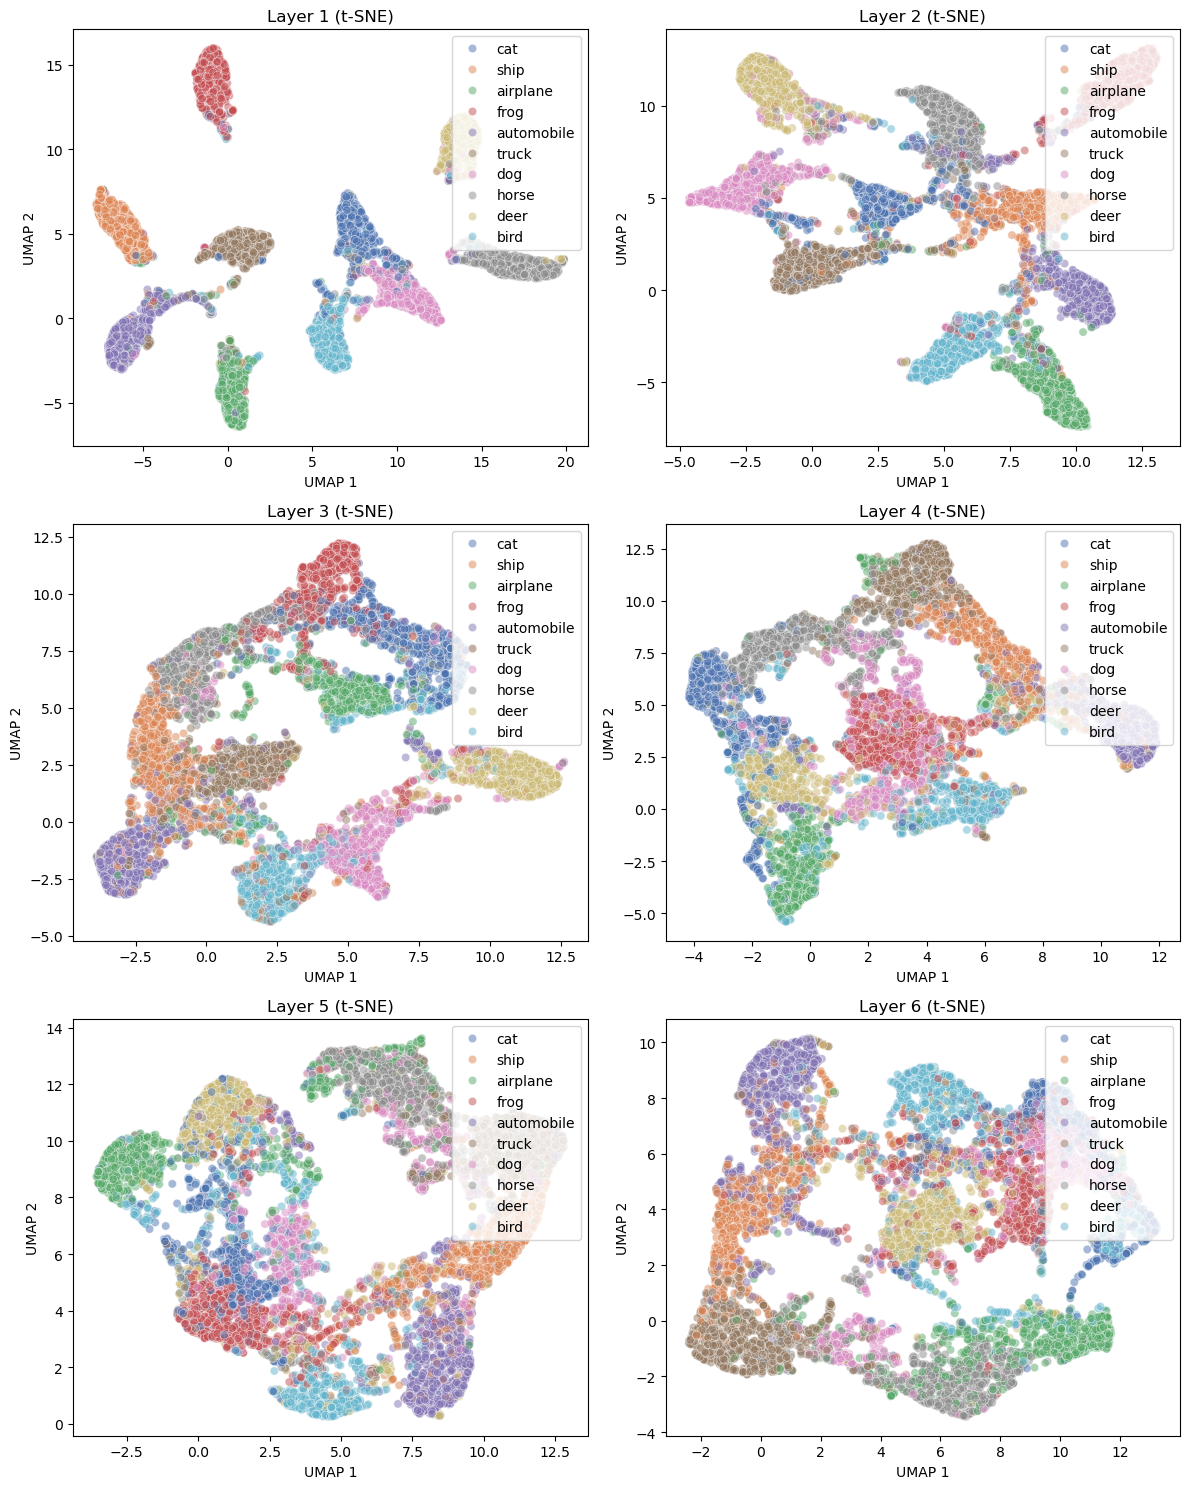

In [114]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    sns.scatterplot(x=umap_results[i][:, 0], y=umap_results[i][:, 1], hue=targets_names, palette='deep', ax=ax, alpha=0.5)
    ax.set_title(f'Layer {i+1} (t-SNE)')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("images/umap_flow.svg", format='svg')
plt.show()